In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
from scipy.optimize import newton

In [2]:
def simple_plot(func, x0, r, n_points=1000):
    plt.figure(figsize=(10, 6))
    x = np.linspace(x0 - r, x0 + r, n_points)
    y = func(x)
    plt.plot(x, y)
    plt.axvline(x0, color="r", linestyle="--")
    # plt.text(x0, 0, f'$x_0$={x0}', fontsize=12, verticalalignment='bottom')
    plt.title(f'Wykres funkcji "{func.__name__}"')
    plt.xlabel("x")
    plt.ylabel("f(x)")
    plt.grid()
    plt.show()

# Zadanie 1

Dla poniższych funkcji i punktów początkowych metoda Newtona zawodzi. Wyjaśnij dlaczego. Następnie znajdź pierwiastki, modyfikując wywołanie funkcji `scipy.optimize.newton` lub używając innej metody.

(a) $ f(x) = x^3 - 5x , \ x_0 = 1 $

(b) $ f(x) = x^3 - 3x + 1 , \ x_0 = 1 $

(c) $ f(x) = 2 - x^5 , \ x_0 = 0.01 $

(d) $ f(x) = x^4 - 4.29x^2 - 5.29 , \ x_0 = 0.8 $

In [3]:
def f_a(x=1):
    return x**3 - 5 * x


def f_b(x=1):
    return x**3 - 3 * x + 1


def f_c(x=0.01):
    return 2 - x**5


def f_d(x=0.8):
    return x**4 - 4.29 * x**2 - 5.29

Obliczone pochodne funkcji.

(a) $ f'(x) = 3x^2 - 5 $

(b) $ f'(x) = 3x^2 - 3 $

(c) $ f'(x) = -5x^4 $

(d) $ f'(x) = 4x^3 - 8.58 x $

In [4]:
# Necessary for `scipy.optimize.newton`
# ("The Newton-Raphson method is used if the derivative fprime of func is provided.")


def f_a_prime(x=1):
    return 3 * x**2 - 5


def f_b_prime(x=1):
    return 3 * x**2 - 3


def f_c_prime(x=0.01):
    return -5 * x**4


def f_d_prime(x=0.8):
    return 4 * x**3 - 8.58 * x

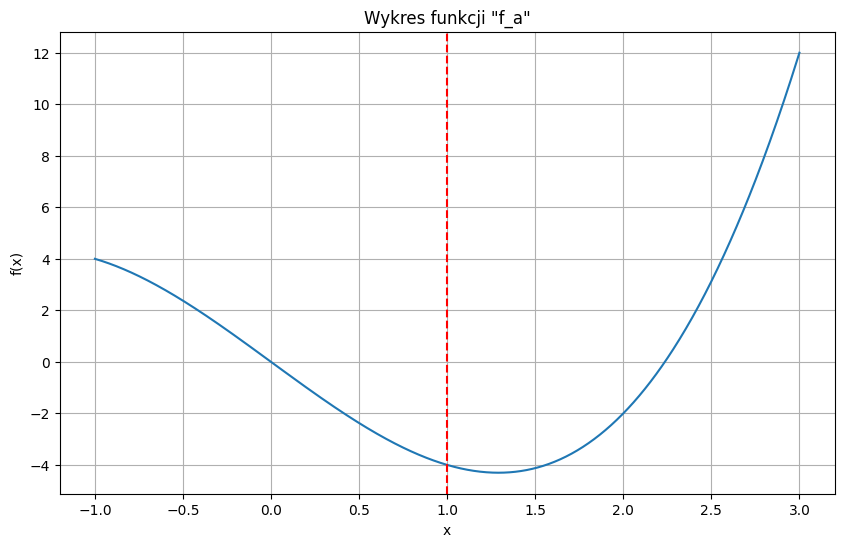

Failed to converge after 50 iterations, value is 1.0.


In [5]:
simple_plot(f_a, 1, 2)
try:
    result = newton(func=f_a, x0=1, fprime=f_a_prime, full_output=True)
    print(result)
except RuntimeError as e:
    print(e)

Metoda Newtona zawodzi, ponieważ algorytm zapętla się:

$ x_0 = 1 $: &nbsp;&nbsp;&nbsp;&nbsp; $ x_1 = x_0 - f(x_0)/f'(x_0) = -1 $

$ x_1 = -1 $: &nbsp;&nbsp;&nbsp;&nbsp; $ x_2 = x_1 - f(x_1)/f'(x_1) = 1 $

$ x_2 = 1 $: &nbsp;&nbsp;&nbsp;&nbsp; $ x_1 = x_0 - f(x_0)/f'(x_0) = -1 $

$ ... $

Aby otrzymać poprawną wartość możemy zmienić $x_0$.

In [6]:
result = newton(func=f_a, x0=1 + 0.001, fprime=f_a_prime, full_output=True)
print(result)

(2.23606797749979,       converged: True
           flag: converged
 function_calls: 28
     iterations: 14
           root: 2.23606797749979
         method: newton)


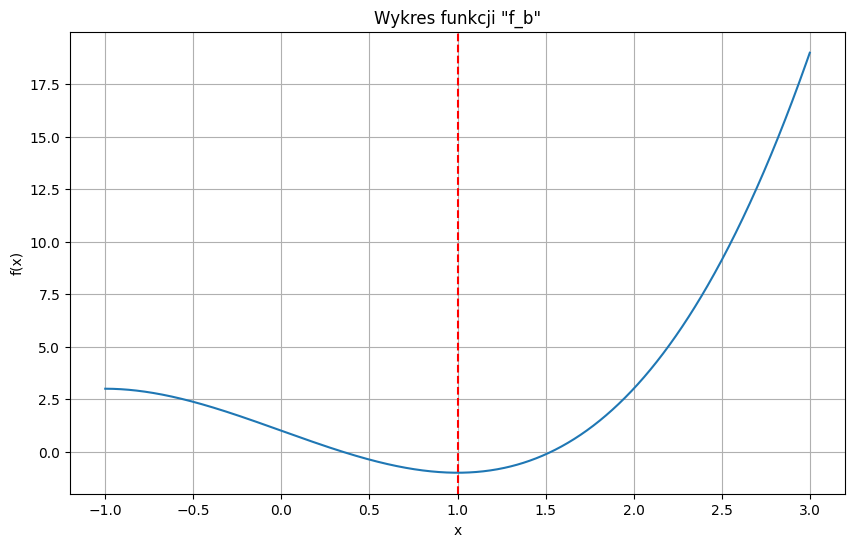

Derivative was zero. Failed to converge after 1 iterations, value is 1.0.


In [7]:
simple_plot(f_b, 1, 2)
try:
    result = newton(func=f_b, x0=1, fprime=f_b_prime, full_output=True)
    print(result)
except RuntimeError as e:
    print(e)

Metoda Newtona zawodzi, ponieważ pochodna zeruje się w $x_0$($= 1$):

$ f'(x_0 = 1) = 0 $

Aby otrzymać poprawną wartość możemy zmienić $x_0$.

In [8]:
result = newton(func=f_b, x0=1 + 0.001, fprime=f_b_prime, full_output=True)
print(result)

(1.532088886237956,       converged: True
           flag: converged
 function_calls: 36
     iterations: 18
           root: 1.532088886237956
         method: newton)


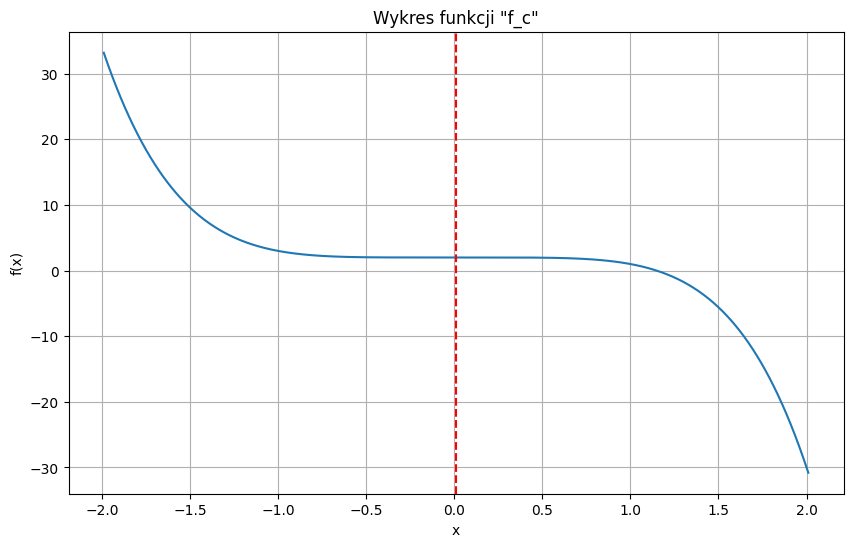

Failed to converge after 50 iterations, value is 713.6238464957056.


In [9]:
simple_plot(f_c, 0.01, 2)
try:
    result = newton(func=f_c, x0=0.01, fprime=f_c_prime, full_output=True)
    print(result)
except RuntimeError as e:
    print(e)

Metoda Newtona zawodzi, ponieważ funkcja jest bliska funkcji stałej w okolicy $x=0$, z tego powodu pierwiastek nie zostaje znaleziony przed przekroczeniem limitu iteracji.

Aby otrzymać poprawną wartość możemy zmienić $x_0$ na wartość bliższą miejscu zerowemu lub zwiększyć ilość iteracji.

In [10]:
result = newton(func=f_c, x0=0.01, fprime=f_c_prime, maxiter=100, full_output=True)
print(result)

(1.148698354997035,       converged: True
           flag: converged
 function_calls: 168
     iterations: 84
           root: 1.148698354997035
         method: newton)


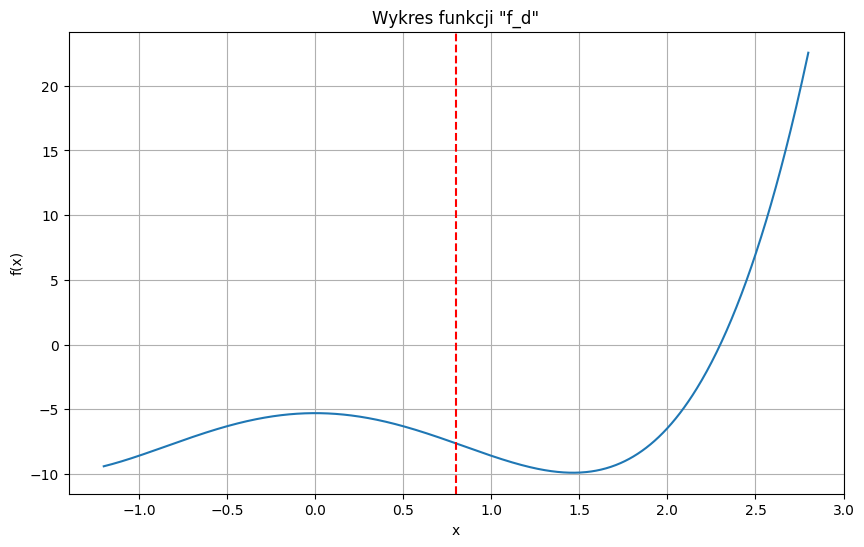

Failed to converge after 50 iterations, value is 0.7876130494100906.


In [11]:
simple_plot(f_d, 0.8, 2)
try:
    result = newton(func=f_d, x0=0.8, fprime=f_d_prime, full_output=True)
    print(result)
except RuntimeError as e:
    print(e)

In [12]:
x_i = 0.8
for i in range(0, 6):
    x_i_p1 = x_i - f_d(x_i) / f_d_prime(x_i)
    print(f"x_{i} = {x_i:.3f}\t: x_{i} - f(x_{i})/f'(x_{i}) = {x_i_p1:.3f}")
    x_i = x_i_p1

x_0 = 0.800	: x_0 - f(x_0)/f'(x_0) = -0.783
x_1 = -0.783	: x_1 - f(x_1)/f'(x_1) = 0.789
x_2 = 0.789	: x_2 - f(x_2)/f'(x_2) = -0.787
x_3 = -0.787	: x_3 - f(x_3)/f'(x_3) = 0.788
x_4 = 0.788	: x_4 - f(x_4)/f'(x_4) = -0.788
x_5 = -0.788	: x_5 - f(x_5)/f'(x_5) = 0.788


Metoda Newtona zawodzi, ponieważ algorytm zapętla się podobnie jak dla funkcji (a).

Aby otrzymać poprawną wartość możemy spróbować przenieść punkt startowy $x_0$.

In [13]:
result = newton(func=f_d, x0=0.8 + 1, fprime=f_d_prime, full_output=True)
print(result)

(2.3,       converged: True
           flag: converged
 function_calls: 14
     iterations: 7
           root: 2.3
         method: newton)


# Zadanie 2

Dane jest równanie:

$$ f(x) = x^2 - 3x + 2 = 0 \tag{1} $$

Każda z następujących funkcji definiuje równoważny schemat iteracyjny:

$$ g_1(x) = (x^2 + 2) / 3 \tag{2} $$
$$ g_2(x) = \sqrt{3x - 2} \tag{3} $$
$$ g_3(x) = 3 - 2 / x \tag{4} $$
$$ g_4(x) = (x^2 - 2) / (2x - 3) \tag{5} $$

In [14]:
def g_1(x):
    return (x**2 + 2) / 3


def g_2(x):
    return (3 * x - 2) ** 0.5


def g_3(x):
    return 3 - 2 / x


def g_4(x):
    return (x**2 - 2) / (2 * x - 3)

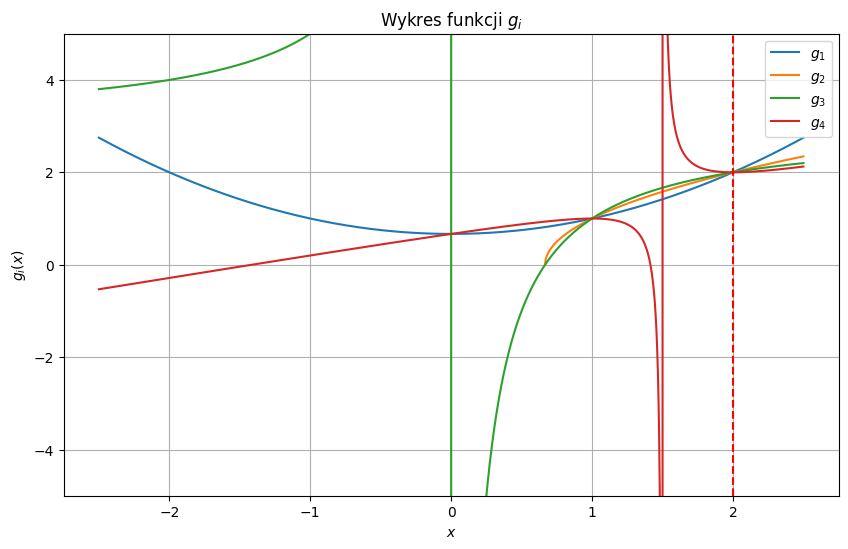

In [15]:
plt.figure(figsize=(10, 6))
x = np.linspace(-2.5, 2.5, 10000)
x2 = np.linspace(0.667, 2.5, 10000)
plt.ylim(-5, 5)
plt.plot(x, g_1(x), label=r"$g_1$")
plt.plot(x2, g_2(x2), label=r"$g_2$")
plt.plot(x, g_3(x), label=r"$g_3$")
plt.plot(x, g_4(x), label=r"$g_4$")
plt.axvline(2, color="r", linestyle="--")
plt.title(r"Wykres funkcji $g_i$")
plt.xlabel(r"$x$")
plt.ylabel(r"$g_i(x)$")
plt.legend()
plt.grid()
plt.show()

Obliczone pochodne funkcji.

$ g_1'(x) = \frac{2}{3}x $

$ g_2'(x) = \frac{3}{2\sqrt{3x - 2}} $

$ g_3'(x) = \frac{2}{x^2} $

$ g_4'(x) = \frac{2x^2 - 6x + 4}{4x^2 - 12x + 9} $

In [16]:
def g_1_prime(x):
    return 2 * x / 3


def g_2_prime(x):
    return 3 / (2 * (3 * x - 2) ** 0.5)


def g_3_prime(x):
    return 2 / x**2


def g_4_prime(x):
    return (2 * x**2 - 6 * x + 4) / (4 * x**2 - 12 * x + 9)

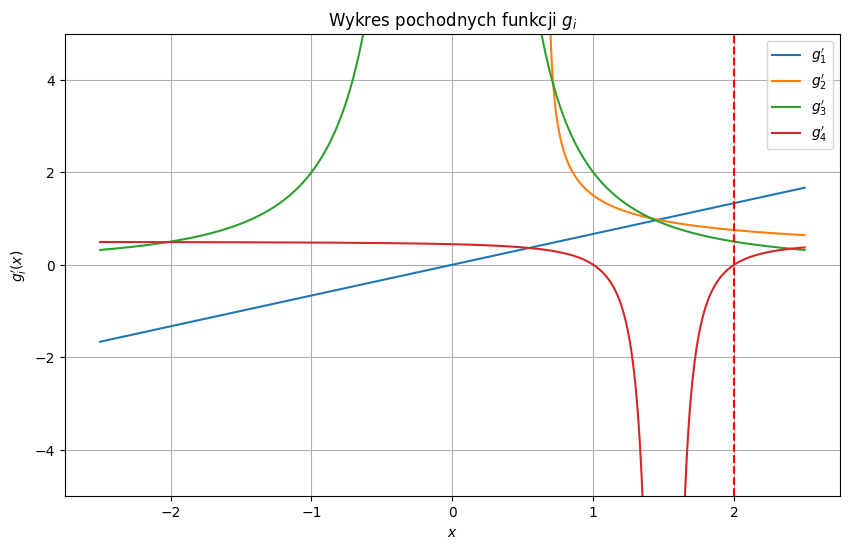

In [17]:
plt.figure(figsize=(10, 6))
x = np.linspace(-2.5, 2.5, 10000)
x2 = np.linspace(0.667, 2.5, 10000)
plt.ylim(-5, 5)
plt.plot(x, g_1_prime(x), label=r"$g_1'$")
plt.plot(x2, g_2_prime(x2), label=r"$g_2'$")
plt.plot(x, g_3_prime(x), label=r"$g_3'$")
plt.plot(x, g_4_prime(x), label=r"$g_4'$")
plt.axvline(2, color="r", linestyle="--")
plt.title(r"Wykres pochodnych funkcji $g_i$")
plt.xlabel(r"$x$")
plt.ylabel(r"$g_i'(x)$")
plt.legend()
plt.grid()
plt.show()

### (a)

Przeanalizuj zbieżność oraz rząd zbieżności schematów iteracyjnych odpowiadających funkcjom $g_i(x)$ dla pierwiastka $x = 2$ badając wartość $|g_i'(2)|$.


In [18]:
print(f"g_1'(2) = {g_1_prime(2):.3f}")
print(f"g_2'(2) = {g_2_prime(2):.3f}")
print(f"g_3'(2) = {g_3_prime(2):.3f}")
print(f"g_4'(2) = {g_4_prime(2):.3f}")

g_1'(2) = 1.333
g_2'(2) = 0.750
g_3'(2) = 0.500
g_4'(2) = 0.000


Zbieżne są schematy iteracyjne odpowiadające funkcjom:

- $|g_2'(2)| = 0.750 < 1$

- $|g_3'(2)| = 0.500 < 1$

- $|g_4'(2)| = 0.000 < 1$ (rząd zbieżności co najmniej $2$)

Nie jest zbieżny schemat:

- $|g_1'(2)| = 1.333 > 1$

### (b)

Potwierdź analizę teoretyczną implementując powyższe schematy iteracyjne i weryfikując ich zbieżność (lub brak). Każdy schemat iteracyjny wykonaj przez $10$ iteracji.

Wyznacz eksperymentalnie rząd zbieżności każdej metody iteracyjnej ze wzoru

$$ r = \frac{\ln{\frac{\varepsilon_{k}}{\varepsilon_{k+1}}}}{\ln{\frac{\varepsilon_{k-1}}{\varepsilon_{k}}}} \tag{6} $$

gdzie błąd bezwzględny $\varepsilon_k$ definiujemy jako $\varepsilon_k = |x_k − x_∗|$, $x_k$ jest przybliżeniem pierwiastka w $k$-tej iteracji, a $x_∗$ dokładnym położeniem pierwiastka równania.

In [19]:
def iteration_scheme(g, x0, max_iter=10):
    root_approx = [x0]
    for _ in range(max_iter):
        x_k = g(root_approx[-1])
        root_approx.append(x_k)
    return root_approx

In [20]:
x0 = 3  # Initial starting point based on the graph
g_1_iter = iteration_scheme(g_1, x0)
g_2_iter = iteration_scheme(g_2, x0)
g_3_iter = iteration_scheme(g_3, x0)
g_4_iter = iteration_scheme(g_4, x0)
pd.DataFrame({
    "g_1": g_1_iter,
    "g_2": g_2_iter,
    "g_3": g_3_iter,
    "g_4": g_4_iter
}).style.format("{:.2e}")

,g_1,g_2,g_3,g_4
0,3.00e+00,3.00e+00,3.00e+00,3.00e+00
1,3.67e+00,2.65e+00,2.33e+00,2.33e+00
2,5.15e+00,2.44e+00,2.14e+00,2.07e+00
3,9.50e+00,2.30e+00,2.07e+00,2.00e+00
4,3.08e+01,2.22e+00,2.03e+00,2.00e+00
5,3.16e+02,2.16e+00,2.02e+00,2.00e+00
6,3.33e+04,2.11e+00,2.01e+00,2.00e+00
7,3.69e+08,2.08e+00,2.00e+00,2.00e+00
8,4.55e+16,2.06e+00,2.00e+00,2.00e+00
9,6.89e+32,2.05e+00,2.00e+00,2.00e+00


In [21]:
g_1_error = [abs(x - 2) for x in g_1_iter]
g_2_error = [abs(x - 2) for x in g_2_iter]
g_3_error = [abs(x - 2) for x in g_3_iter]
g_4_error = [abs(x - 2) for x in g_4_iter]

g_1_rate = 0 if g_1_error[-1] == 0 or g_1_error[-2] == 0 else np.log(g_1_error[-2] / g_1_error[-1]) / np.log(g_1_error[-3] / g_1_error[-2])

g_2_rate = 0 if g_2_error[-1] == 0 or g_2_error[-2] == 0 else np.log(g_2_error[-2] / g_2_error[-1]) / np.log(g_2_error[-3] / g_2_error[-2])

g_3_rate = 0 if g_3_error[-1] == 0 or g_3_error[-2] == 0 else np.log(g_3_error[-2] / g_3_error[-1]) / np.log(g_3_error[-3] / g_3_error[-2])

g_4_rate = 0 if g_4_error[-1] == 0 or g_4_error[-2] == 0 else np.log(g_4_error[-2] / g_4_error[-1]) / np.log(g_4_error[-3] / g_4_error[-2])

print(f"g_1: {g_1_rate:.3f}")
print(f"g_2: {g_2_rate:.3f}")
print(f"g_3: {g_3_rate:.3f}")
print(f"g_4: {g_4_rate:.3f}")

g_1: 2.000
g_2: 0.990
g_3: 0.999
g_4: 0.000


### (c)

Na wspólnym rysunku przedstaw wykresy błędu względnego każdej metody w zależności od numeru iteracji. Użyj skali logarytmicznej na osi $y$ (pomocna będzie funkcja `semilogy`).

Stwórz drugi rysunek, przedstawiający wykresy błędu względnego tylko dla metod zbieżnych.

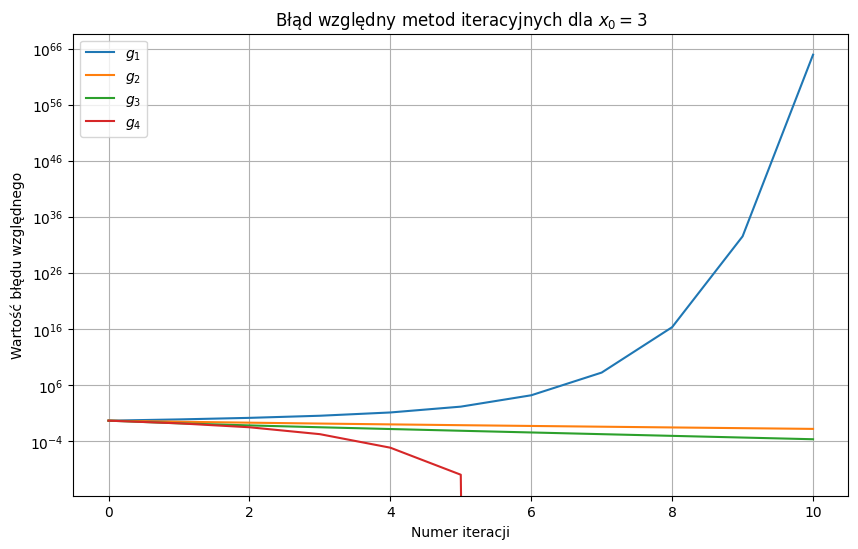

In [22]:
plt.figure(figsize=(10, 6))
plt.title(f"Błąd względny metod iteracyjnych dla $x_0 = {x0}$")
plt.semilogy([error / 2 for error in g_1_error], label=r"$g_1$")
plt.semilogy([error / 2 for error in g_2_error], label=r"$g_2$")
plt.semilogy([error / 2 for error in g_3_error], label=r"$g_3$")
plt.semilogy([error / 2 for error in g_4_error], label=r"$g_4$")
plt.xlabel("Numer iteracji")
plt.ylabel("Wartość błędu względnego")
plt.legend()
plt.grid()
plt.show()

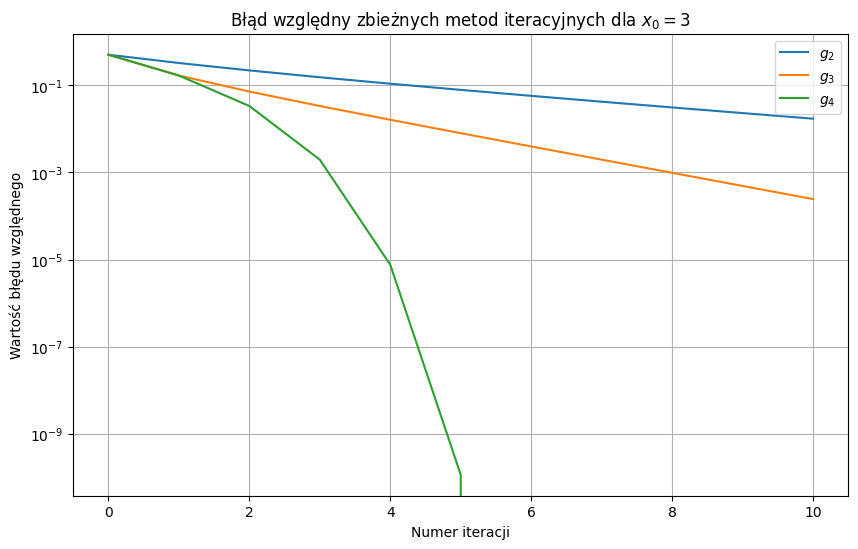

In [23]:
plt.figure(figsize=(10, 6))
plt.title(f"Błąd względny zbieżnych metod iteracyjnych dla $x_0 = {x0}$")
plt.semilogy([error / 2 for error in g_2_error], label=r"$g_2$")
plt.semilogy([error / 2 for error in g_3_error], label=r"$g_3$")
plt.semilogy([error / 2 for error in g_4_error], label=r"$g_4$")
plt.xlabel("Numer iteracji")
plt.ylabel("Wartość błędu względnego")
plt.legend()
plt.grid()
plt.show()

# Zadanie 3

Napisz schemat iteracji wg metody Newtona dla każdego z następujących równań nieliniowych:

(a) $ x^3 - 2x - 5 = 0 $

(b) $ e^{-x} = x $

(c) $ x \sin{x} = 1 $.

In [24]:
def f_a(x):
    return x**3 - 2 * x - 5


def f_b(x):
    return np.exp(-x) - x


def f_c(x):
    return x * np.sin(x) - 1

Obliczone pochodne funkcji.

(a) $ f'(x) = 3x^2 - 2 $

(b) $ f'(x) = -e^{-x} - 1 $

(c) $ f'(x) = \sin{x} + x\cos{x} $

In [25]:
def f_a_prime(x):
    return 3 * x**2 - 2


def f_b_prime(x):
    return -np.exp(-x) - 1


def f_c_prime(x):
    return np.sin(x) + x * np.cos(x)

In [26]:
f_a_result = {}
f_b_result = {}
f_c_result = {}

f_a_result["4-bit"] = newton(
    func=f_a,
    x0=1,
    fprime=f_a_prime,
    full_output=True,
    tol=2**-4,
)
f_b_result["4-bit"] = newton(
    func=f_b,
    x0=1,
    fprime=f_b_prime,
    full_output=True,
    tol=2**-4,
)
f_c_result["4-bit"] = newton(
    func=f_c,
    x0=1,
    fprime=f_c_prime,
    full_output=True,
    tol=2**-4,
)

print(f'f_a 4-bit tol. iterations: {f_a_result["4-bit"][1]["iterations"]}')
print(f'f_b 4-bit tol. iterations: {f_b_result["4-bit"][1]["iterations"]}')
print(f'f_c 4-bit tol. iterations: {f_c_result["4-bit"][1]["iterations"]}')

f_a 4-bit tol. iterations: 7
f_b 4-bit tol. iterations: 2
f_c 4-bit tol. iterations: 2


Jeśli $x_0$ jest przybliżeniem pierwiastka z dokładnością $4$ bitów, ile iteracji należy wykonać aby osiągnąć:

- $24$-bitową dokładność (`float32`)

- $53$-bitową dokładność (`float64`)?

Zbieżność metody Newtona jest kwadratowa, a więc oczekujemy, że każda iteracja będzie podwajać liczbę otrzymanych cyfr precyzji.

In [27]:
f_a_result["24-bit"] = newton(
    func=f_a,
    x0=f_a_result["4-bit"][0],
    fprime=f_a_prime,
    full_output=True,
    tol=2**-24,
)
f_b_result["24-bit"] = newton(
    func=f_b,
    x0=f_b_result["4-bit"][0],
    fprime=f_b_prime,
    full_output=True,
    tol=2**-24,
)
f_c_result["24-bit"] = newton(
    func=f_c,
    x0=f_c_result["4-bit"][0],
    fprime=f_c_prime,
    full_output=True,
    tol=2**-24,
)

print(f'f_a 24-bit tol. iterations: {f_a_result["24-bit"][1]["iterations"]}')
print(f'f_b 24-bit tol. iterations: {f_b_result["24-bit"][1]["iterations"]}')
print(f'f_c 24-bit tol. iterations: {f_c_result["24-bit"][1]["iterations"]}')

f_a 24-bit tol. iterations: 2
f_b 24-bit tol. iterations: 2
f_c 24-bit tol. iterations: 1


In [28]:
tolerance = max(2**-53, np.finfo(float).eps)
print(
    f"Difference between 2^-53 and float64 machine epsilon: {tolerance - np.finfo(float).eps:.3e}"
)

f_a_result["53-bit"] = newton(
    func=f_a,
    x0=f_a_result["4-bit"][0],
    fprime=f_a_prime,
    full_output=True,
    tol=tolerance,
)
f_b_result["53-bit"] = newton(
    func=f_b,
    x0=f_b_result["4-bit"][0],
    fprime=f_b_prime,
    full_output=True,
    tol=tolerance,
)
f_c_result["53-bit"] = newton(
    func=f_c,
    x0=f_c_result["4-bit"][0],
    fprime=f_c_prime,
    full_output=True,
    tol=tolerance,
)

print(f'f_a 53-bit tol. iterations: {f_a_result["53-bit"][1]["iterations"]}')
print(f'f_b 53-bit tol. iterations: {f_b_result["53-bit"][1]["iterations"]}')
print(f'f_c 53-bit tol. iterations: {f_c_result["53-bit"][1]["iterations"]}')

Difference between 2^-53 and float64 machine epsilon: 0.000e+00
f_a 53-bit tol. iterations: 3
f_b 53-bit tol. iterations: 3
f_c 53-bit tol. iterations: 2


# Zadanie 4

Napisz schemat iteracji wg metody Newtona dla następującego układu równań nieliniowych:

$ x_1^2 + x_2^2 = 1 $

$ x_1^2 - x_2 = 0 $.

Korzystając z faktu, że dokładne rozwiązanie powyższego układu równań to:

$$ x_1 = \pm \sqrt{\frac{\sqrt{5}}{2} - \frac{1}{2}} \tag{7a} $$

$$ x_2 = \frac{\sqrt{5}}{2} - \frac{1}{2} \tag{7b} $$

oblicz błąd względny rozwiązania znalezionego metodą Newtona.

Układ równań
$$
\begin{cases}
f_1(x_1, x_2) = x_1^2 + x_2^2 - 1 = 0 \\ 
f_2(x_1, x_2) = x_1^2 - x_2 = 0
\end{cases}
$$

Wektor $\boldsymbol{x}$
$$
\boldsymbol{x} = 
\begin{bmatrix}
{x_1} & {x_2}
\end{bmatrix}
$$

Definicja funkcji $F(\boldsymbol{x})$
$$
F(\boldsymbol{x}) =
\begin{bmatrix}
f_1(x_1, x_2) \\
f_2(x_1, x_2)
\end{bmatrix} =
\begin{bmatrix}
x_1^2 + x_2^2 - 1 \\
x_1^2 - x_2
\end{bmatrix}
$$

Jakobian układu
$$
J_F(\boldsymbol{x}) =
\begin{bmatrix}
\frac{\partial{f_1}}{\partial{x_1}} & \frac{\partial{f_1}}{\partial{x_2}} \\
\frac{\partial{f_2}}{\partial{x_1}} & \frac{\partial{f_2}}{\partial{x_2}}
\end{bmatrix} =
\begin{bmatrix}
2x_1 & 2x_2 \\
2x_1 & -1
\end{bmatrix}
$$

Iteracja Newtona
$$
\boldsymbol{x}_{k+1} = \boldsymbol{x}_{k} + \Delta{\boldsymbol{x}}
$$
gdzie $\boldsymbol{x}_{k}$ to wektor wartości przybliżonych w kroku $k$, a krok jest obliczany poprzez rozwiązanie równania
$$
J_F(\boldsymbol{x}_{k}) \Delta{\boldsymbol{x}} = - F(\boldsymbol{x}_{k})
$$

In [29]:
def F(x):
    x1, x2 = x
    return np.array([x1**2 + x2**2 - 1, x1**2 - x2])


def J(x):
    x1, x2 = x
    return np.array([[2 * x1, 2 * x2], [2 * x1, -1]])


def newton_method(x0, max_iter=10):
    root_approx = [x0]
    for _ in range(max_iter):
        x = root_approx[-1]
        delta_x = np.linalg.solve(J(x), -F(x))
        root_approx.append(x + delta_x)
    return root_approx

In [30]:
exact_x1 = np.sqrt((np.sqrt(5) / 2) - 0.5)
exact_x2 = (np.sqrt(5) / 2) - 0.5
print(f"Exact x1: {exact_x1:.2e}")
print(f"Exact x2: {exact_x2:.2e}")

x0 = np.array([1, 1])

root_approx = newton_method(x0)

error_x1 = [abs(root[0] - exact_x1) / abs(exact_x1) for root in root_approx]
error_x2 = [abs(root[1] - exact_x2) / abs(exact_x2) for root in root_approx]

pd.DataFrame(
    {
        "x1": [root[0] for root in root_approx],
        "rel_error_x1": error_x1,
        "x2": [root[1] for root in root_approx],
        "rel_error_x2": error_x2,
    }
).style.format("{:.2e}")

Exact x1: 7.86e-01
Exact x2: 6.18e-01


,x1,rel_error_x1,x2,rel_error_x2
0,1.00e+00,2.72e-01,1.00e+00,6.18e-01
1,8.33e-01,6.00e-02,6.67e-01,7.87e-02
2,7.88e-01,2.47e-03,6.19e-01,1.64e-03
3,7.86e-01,3.42e-06,6.18e-01,7.43e-07
4,7.86e-01,5.92e-12,6.18e-01,1.52e-13
5,7.86e-01,0.00e+00,6.18e-01,1.80e-16
6,7.86e-01,0.00e+00,6.18e-01,1.80e-16
7,7.86e-01,0.00e+00,6.18e-01,1.80e-16
8,7.86e-01,0.00e+00,6.18e-01,1.80e-16
9,7.86e-01,0.00e+00,6.18e-01,1.80e-16


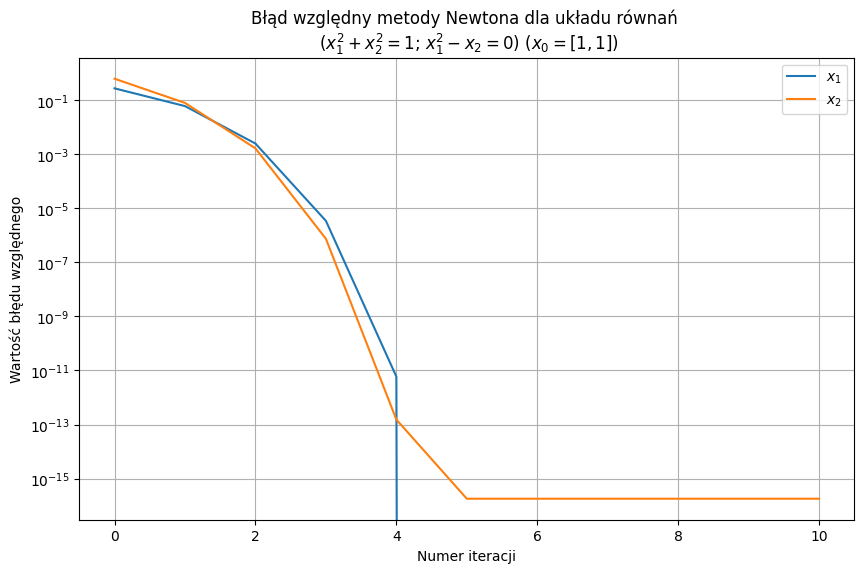

In [31]:
plt.figure(figsize=(10, 6))
plt.title(
    f"Błąd względny metody Newtona dla układu równań \n ($ x_1^2 + x_2^2 = 1 $; $ x_1^2 - x_2 = 0 $) ($x_0 = [{x0[0]}, {x0[1]}]$)"
)
plt.semilogy(error_x1, label=r"$x_1$")
plt.semilogy(error_x2, label=r"$x_2$")
plt.xlabel("Numer iteracji")
plt.ylabel("Wartość błędu względnego")
plt.legend()
plt.grid()
plt.show()